In [2]:
import pandas as pd # import pandas as pd
import numpy as np # import numpy as np
import matplotlib.pyplot as plt # import matplotlib.pyplot as plt
import seaborn as sns # import seaborn as sns

In [3]:
df = pd.read_csv("loan_data.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.shape # for the number of rows and columns in the dataset

(614, 13)

In [5]:
df.columns # for the column names in the dataset

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [6]:
df.info() # for the data types and null values in the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [7]:
df.isnull().sum() # for the number of null values in each column

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [8]:
(df.isnull().sum()/len(df))*100 # for the percentage of null values in each column

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [9]:
df.describe() # for the statistical summary of the dataset

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [10]:
df['Gender'].value_counts() # for categorical data, we use value_counts() to get the count of each category.

Gender
Male      489
Female    112
Name: count, dtype: int64

In [11]:
df['Married'].value_counts() # for categorical data, we use value_counts() to get the count of each category.

Married
Yes    398
No     213
Name: count, dtype: int64

In [12]:
df["Education"].value_counts() # for categorical data, we use value_counts() to get the count of each category.

Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

In [13]:
df['Loan_Status'].value_counts() # for categorical data, we use value_counts() to get the count of each category.

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [14]:
df["LoanAmount"].isnull().sum() # for the number of null values in the LoanAmount column

np.int64(22)

In [15]:
df["LoanAmount"].median() # median use because it is less affected by outliers and skewed data.


np.float64(128.0)

In [16]:
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median()) # fill the null values in the LoanAmount column with the median value
df['LoanAmount'].isnull().sum() # to check if the null values in the LoanAmount column are filled or not

np.int64(0)

In [17]:
df["Loan_Amount_Term"].isnull().sum() # for the number of null values in the Loan_Amount_Term column


np.int64(14)

In [18]:
# fill the null values in the Loan_Amount_Term column with the median value
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median())
# to check if the null values in the Loan_Amount_Term column are filled or not
df["Loan_Amount_Term"].isnull().sum()

np.int64(0)

In [19]:
# for categorical data, we use value_counts() to get the count of each category.
df["Credit_History"].value_counts() 


Credit_History
1.0    475
0.0     89
Name: count, dtype: int64

In [20]:
# # fill the null values in the Credit_History column with the mode value
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0]) 
df["Credit_History"].isnull().sum() # to check if the null values in the Credit_History column are filled or not    

np.int64(0)

In [21]:
# call isnull on the dataframe 'df' defined in previous cells
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [22]:
# fill the null values in the Gender, Married, Dependents, and Self_Employed columns with the mode value
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

df['Married'] = df['Married'].fillna(df['Married'].mode()[0])

df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])

df['Self_Employed'] = df['Self_Employed'].fillna(
    df['Self_Employed'].mode()[0]
)

In [23]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

### Q1: What is the overall loan approval rate?


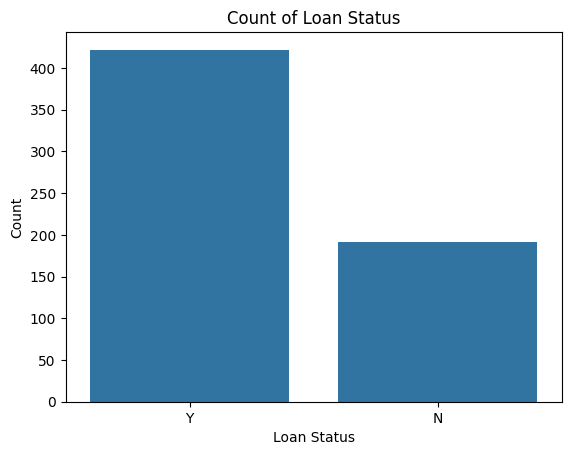

In [24]:
# find 
sns.countplot(x="Loan_Status", data=df) # for the count of each category in the Loan_Status column
plt.title("Count of Loan Status") # for the title of the plot   
plt.xlabel("Loan Status") # for the x-axis label
plt.ylabel("Count") # for the y-axis label
plt.show() # to display the plot


# Business Insight
Out of 614 loan applications, 422 were approved and 192 were rejected. The overall loan approval rate is 68.73%, which indicates that most applicants satisfied the bank's lending requirements.

### Q2: Does Gender Influence Loan Approval?

### Bank wants to know:

### 1-Are males getting more approvals?
### 2-Are females getting more approvals?
### 3-Does gender affect the loan decision?

In [25]:
# first we will create a crosstab to see the relationship between Gender and Loan_Status
pd.crosstab(df['Gender'], df['Loan_Status']) # When we compare one category with another category

Loan_Status,N,Y
Gender,,
Female,37,75
Male,155,347


In [26]:
# we calulate the percentage of loan approval
pd.crosstab(df["Gender"], df["Loan_Status"], normalize="index") # to calculate the percentage of loan approval for each gender  


Loan_Status,N,Y
Gender,,
Female,0.330357,0.669643
Male,0.308765,0.691235


### Observation

Male applicants have a 69.12% approval rate, while female applicants have a 66.96% approval rate.

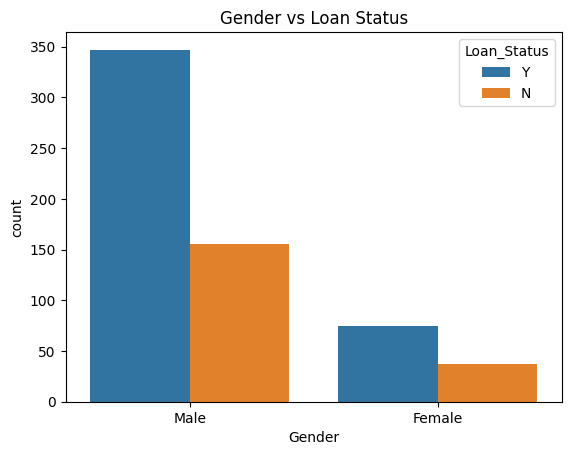

In [27]:
# we create visualization to see the relationship between Gender and Loan_Status
sns.countplot(x="Gender", hue="Loan_Status", data=df)    # for the count of each category in the Gender column with respect to the Loan_Status column
plt.title("Gender vs Loan Status") # for the title of the plot
plt.show() # to display the plot


### Business Insight
Male and female applicants have similar approval rates. Gender does not appear to be a major factor in loan approval decisions.

### Q3: Does Marital Status Influence Loan Approval?


In [28]:
# we find count of approval and rejection for each category in the Married column
pd.crosstab(df["Married"], df["Loan_Status"]) # When we compare one category with another category


Loan_Status,N,Y
Married,,
No,79,134
Yes,113,288


In [29]:
# we find approval percentage for each category in the Married column 
pd.crosstab(df["Married"], df["Loan_Status"], normalize="index") # to calculate the percentage of loan approval for each category in the Married column


Loan_Status,N,Y
Married,,
No,0.370892,0.629108
Yes,0.281796,0.718204


### Observation

Married applicants have an approval rate of 72%, while unmarried applicants have an approval rate of 28%.

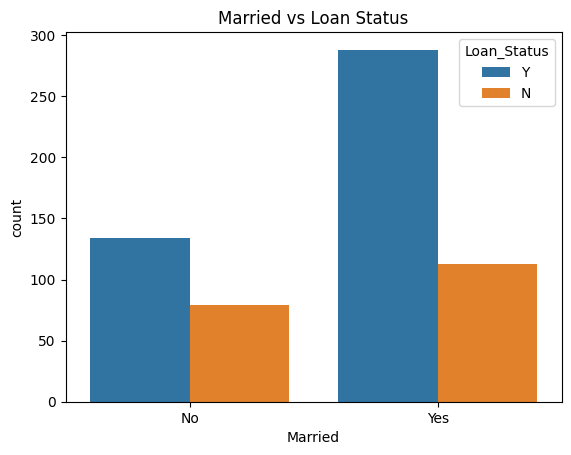

In [30]:
# we create visualization to see the relationship between Married and Loan_Status
sns.countplot(x="Married", hue="Loan_Status", data=df)    # for the count of each category in the Married column with respect to the Loan_Status column
plt.title("Married vs Loan Status") # for the title of the plot
plt.show() # to display the plot

### Business Insight
Married applicants are more likely to receive loan approval, suggesting that marital status may be associated with lower lending risk.

### Q4: Does Education Influence Loan Approval?

In [31]:
# create a crosstab to see the representation of Education and Loan_Status
pd.crosstab(df["Education"], df["Loan_Status"]) # When we compare one category with another category


Loan_Status,N,Y
Education,,
Graduate,140,340
Not Graduate,52,82


In [32]:
# we find loan approval percentage for each category in the Education column 
pd.crosstab(df["Education"], df["Loan_Status"], normalize="index") # to calculate the percentage of loan approval for each category in the Education column


Loan_Status,N,Y
Education,,
Graduate,0.291667,0.708333
Not Graduate,0.388060,0.611940


### Observation
Graduate applicants have an approval rate of 71%, while non-graduate applicants have an approval rate of 61%.

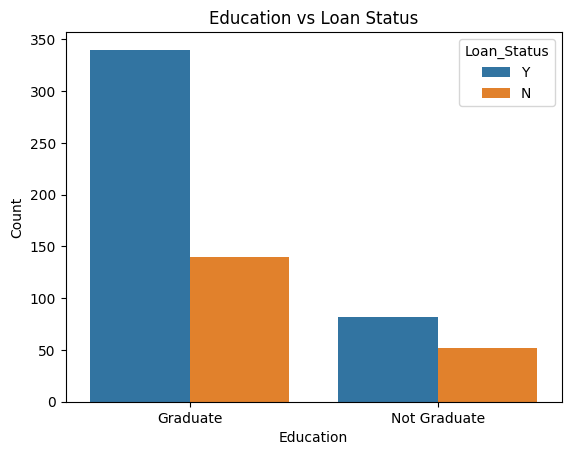

In [33]:
# we create visualization to see the relationship between Education and Loan_Status
sns.countplot(x="Education", hue="Loan_Status", data=df)  # for the count of each category in the Education column with respect to the Loan_Status column
plt.title("Education vs Loan Status")  # for the title of the plot
plt.xlabel("Education")
plt.ylabel("Count")
plt.show() # to display the plot

### Business Insight
Graduate applicants are more likely to receive loan approval, suggesting that education may positively influence lending decisions.

### Q5: Does Self-Employment Influence Loan Approval?

### Bank wants to know:
### 1-Does having your own business affect loan approval?
### 2-Are salaried applicants considered less risky?
### 3-Is self-employment a factor in loan decisions?

In [34]:
# create crosstab to see the relationship between Self_Employed and Loan_Status
pd.crosstab(df["Self_Employed"], df["Loan_Status"]) #we compare one category with another category



Loan_Status,N,Y
Self_Employed,,
No,166,366
Yes,26,56


In [35]:
# we find approval persentage for each category in the Self_Employed column
pd.crosstab(df["Self_Employed"], df["Loan_Status"], normalize="index") # to calculate the percentage of loan approval for each category in the Self_Employed column


Loan_Status,N,Y
Self_Employed,,
No,0.312030,0.687970
Yes,0.317073,0.682927


### Observation

Non-self-employed applicants have an approval rate of 68.80%, while self-employed applicants have an approval rate of 68.29%.

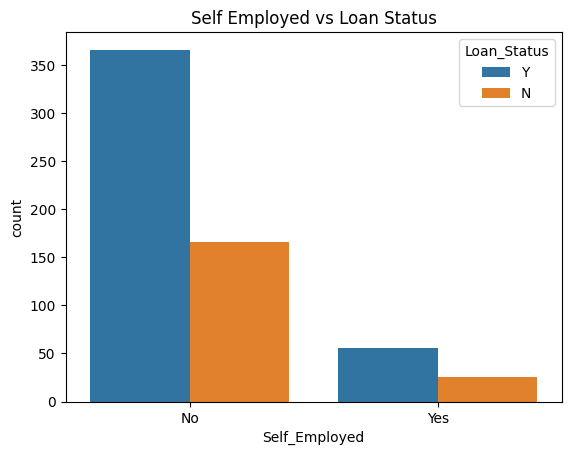

In [36]:
# we create visualization to see the relationship between Self_Employed and Loan_Status
sns.countplot(x="Self_Employed", hue="Loan_Status", data=df)  # for the count of each category in the Self_Employed column with respect to the Loan_Status column
plt.title("Self Employed vs Loan Status")  # for the title of the plot
plt.show() # to display the plot

### Business Insight

Both self-employed and non-self-employed applicants have nearly identical approval rates. Therefore, self-employment status does not significantly influence loan approval decisions.

### Q6: Which Property Area Has the Highest Loan Approval Rate?
Find:

### Which area has the highest approval rate?
### Which area has the lowest approval rate?


In [39]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [40]:
# we find approval percentage for each category in the property_area column
pd.crosstab(df["Property_Area"], df["Loan_Status"], normalize="index") # to calculate the percentage of loan approval for each category in the property_area column


Loan_Status,N,Y
Property_Area,,
Rural,0.385475,0.614525
Semiurban,0.231760,0.768240
Urban,0.341584,0.658416


### Observation 


Rural applicants have an approval rate of 61%.

Urban applicants have an approval rate of 65%.

Semiurban applicants have an approval rate of 76%.

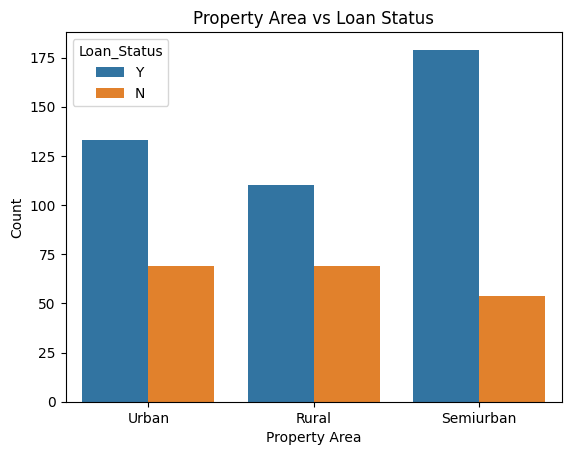

In [41]:
# we create visualization to see the relationship between Property_Area and Loan_Status
sns.countplot(x="Property_Area", hue="Loan_Status", data=df)  # for the count of each category in the Property_Area column with respect to the Loan_Status column
plt.title("Property Area vs Loan Status")  # for the title of the plot
plt.xlabel("Property Area") # for the x-axis label
plt.ylabel("Count") # for the y-axis label
plt.show() # to display the plot

### Business Insight

Semiurban applicants have the highest loan approval rate, suggesting that applicants from semiurban areas may be considered lower risk by the bank.

### Q7: Does Applicant Income Affect Loan Approval?

In [43]:
# we find average income by applicant income for each category in the Loan_Status column
df.groupby("Loan_Status")["ApplicantIncome"].mean() # to calculate the average income by applicant income for each category in the Loan_Status column



Loan_Status
N    5446.078125
Y    5384.068720
Name: ApplicantIncome, dtype: float64

### Observation

The average income of rejected applicants is ₹5446, while the average income of approved applicants is ₹5384.

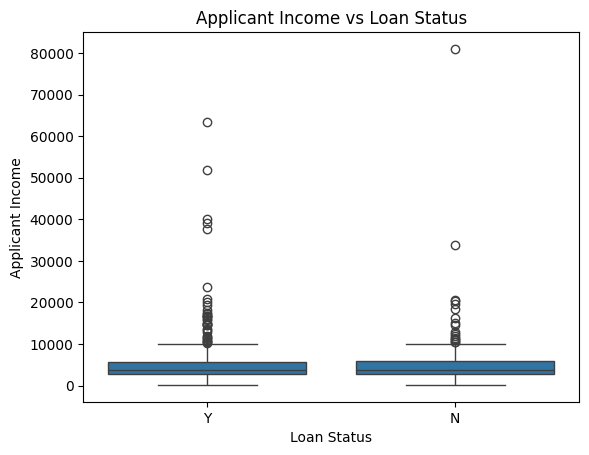

In [44]:
# we create visualization to see the relationship between ApplicantIncome and Loan_Status
sns.boxplot(x="Loan_Status", y="ApplicantIncome", data=df)  # for the boxplot of ApplicantIncome with respect to the Loan_Status column
plt.title("Applicant Income vs Loan Status")  # for the title of the plot
plt.xlabel("Loan Status") # for the x-axis label
plt.ylabel("Applicant Income") # for the y-axis label
plt.show() # to display the plot

### Business Insight

Applicants with higher income are not necessarily getting more loan approvals. Approved and rejected applicants have very similar income distributions.

### Q8: Does Loan Amount Affect Loan Approval?

In [ ]:
# Calculate the average loan amount for approved and rejected loan applications
df.groupby("Loan_Status")["LoanAmount"].mean() # to calculate the average loan amount for approved and rejected loan applications

Loan_Status
N    149.890625
Y    143.869668
Name: LoanAmount, dtype: float64

### Observation
The average loan amount for approved applicants is ₹143.87, while the average loan amount for rejected applicants is ₹149.89.

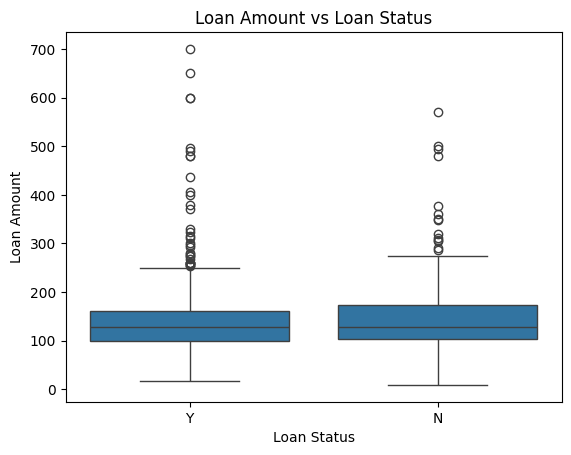

In [46]:
# create visualization to see the relationship between LoanAmount and Loan_Status
sns.boxplot(x="Loan_Status", y="LoanAmount", data=df)  # for the boxplot of LoanAmount with respect to the Loan_Status column
plt.title("Loan Amount vs Loan Status")  # for the title of the plot
plt.xlabel("Loan Status") # for the x-axis label
plt.ylabel("Loan Amount") # for the y-axis label
plt.show() # to display the plot

### Business Insight

Loan amount does not appear to significantly influence loan approval decisions. Approved and rejected applicants requested similar loan amounts, indicating that other factors may play a more important role.

### Q9: Does Credit History Affect Loan Approval?

In [48]:
# calulate the average credit history for approved and rejected loan applications
pd.crosstab(df["Credit_History"], df["Loan_Status"], normalize="index") # to calculate the average credit history for approved and rejected loan applications



Loan_Status,N,Y
Credit_History,,
0.0,0.921348,0.078652
1.0,0.209524,0.790476


### Observation

Applicants with poor credit history have an approval rate of only 7.87%, while applicants with good credit history have an approval rate of 79.05%.

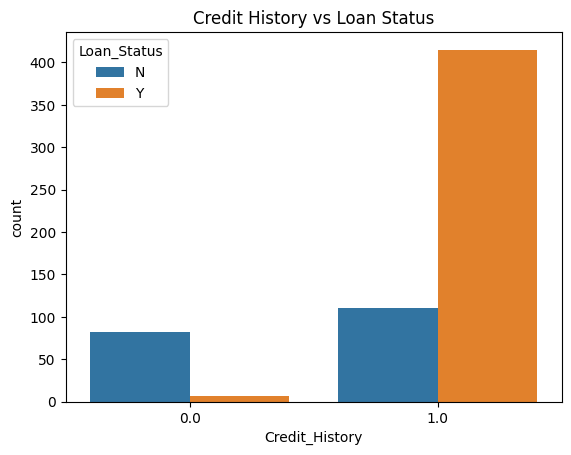

In [50]:
# we create visualization to see the relationship between Credit_History and Loan_Status
sns.countplot(x="Credit_History", hue="Loan_Status", data=df)  # for the count of each category in the Credit_History column with respect to the Loan_Status column
plt.title("Credit History vs Loan Status")  # for the title of the plot
plt.show() # to display the plot

### Business Insight

Credit History is the strongest factor affecting loan approval decisions. Applicants with a good credit history are far more likely to receive loan approval, while applicants with poor credit history face a very high rejection rate.

### Q10: Correlation Analysis

### We want to check relationships between:

### ApplicantIncome
### CoapplicantIncome
### LoanAmount
### Loan_Amount_Term
### Credit_History


In [ ]:
# generate a correlation matrix to see the relationships between numerical columns in the dataset
df.corr(numeric_only=True) # to generate a correlation matrix for the numerical columns in the dataset  


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.116605,0.565181,-0.046531,-0.018615
CoapplicantIncome,-0.116605,1.000000,0.189218,-0.059383,0.011134
LoanAmount,0.565181,0.189218,1.000000,0.036960,-0.000607
Loan_Amount_Term,-0.046531,-0.059383,0.036960,1.000000,-0.004705
Credit_History,-0.018615,0.011134,-0.000607,-0.004705,1.000000


### Observation
### Applicant Income and Loan Amount show a correlation of 0.565, indicating a moderate positive relationship. Applicants with higher incomes tend to request larger loan amounts.

### Credit History has very weak correlations with other numerical features (ranging from -0.019 to 0.011), suggesting that it operates independently of income, loan amount, and loan term.

### Most numerical variables show weak relationships, except for Applicant Income and Loan Amount, which exhibit a moderate positive correlation

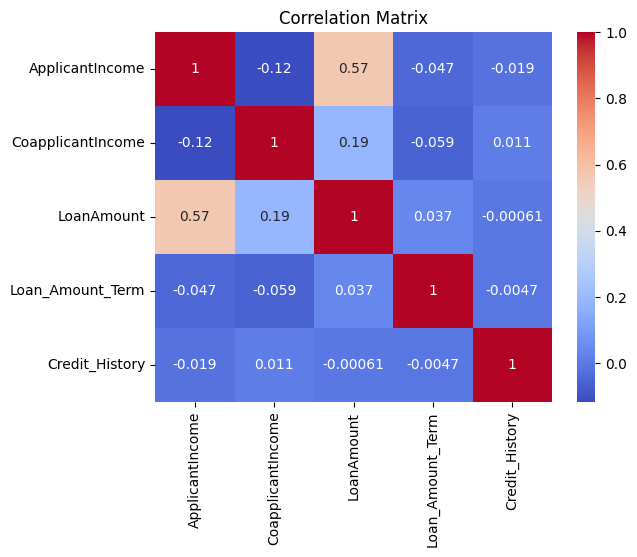

In [52]:
# we create heatmap to visualize the correlation matrix
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")  # to create a heatmap of the correlation matrix
plt.title("Correlation Matrix")  # for the title of the plot
plt.show() # to display the plot

### Business Insight

Income plays a role in determining the loan amount requested, but most other numerical variables operate independently. The strongest relationship in the dataset exists between Applicant Income and Loan Amount.